In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset

import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.amp import GradScaler, autocast
import matplotlib.pyplot as plt

import time
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score

In [2]:
def get_dataloaders(dataset_name, batch_size, pin_memory):
    # ResNet expects 3 channels; we duplicate the grayscale channel
    transform = transforms.Compose([
        transforms.Resize((32, 32)), # Resize slightly for ResNet stability
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    if dataset_name == 'MNIST':
        full_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_data = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else: # FashionMNIST
        full_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_data = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # Merge to re-split according to 70-10-20
    dataset = ConcatDataset([full_data, test_data])
    total_len = len(dataset)
    train_len = int(0.7 * total_len)
    val_len = int(0.1 * total_len)
    test_len = total_len - train_len - val_len

    train_set, val_set, test_set = random_split(dataset, [train_len, val_len, test_len])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory)

    return train_loader, val_loader, test_loader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_model(model_name, num_classes=10):
    if model_name == 'ResNet-18':
        model = models.resnet18(weights=None)
    else:
        model = models.resnet50(weights=None)

    # Modify final layer for 10 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def train_and_evaluate(dataset_name, model_name, batch_size, opt_name, lr, epochs, pin_memory):
    print(f"Running: {dataset_name} | {model_name} | BS:{batch_size} | {opt_name} | LR:{lr}")

    train_loader, val_loader, test_loader = get_dataloaders(dataset_name, batch_size, pin_memory)
    model = get_model(model_name)

    criterion = nn.CrossEntropyLoss()
    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    scaler = GradScaler()
    train_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # FIX: Added device_type='cuda'
            with autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} Loss: {avg_loss:.4f}")

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy, train_losses

Running: MNIST | ResNet-18 | BS:16 | SGD | LR:0.001


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 515kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


Epoch 1/5 Loss: 0.1608
Epoch 2/5 Loss: 0.0583
Epoch 3/5 Loss: 0.0353
Epoch 4/5 Loss: 0.0246
Epoch 5/5 Loss: 0.0193
Running: MNIST | ResNet-50 | BS:16 | SGD | LR:0.001
Epoch 1/5 Loss: 0.4731
Epoch 2/5 Loss: 0.1044
Epoch 3/5 Loss: 0.0615
Epoch 4/5 Loss: 0.0440
Epoch 5/5 Loss: 0.0325
Running: MNIST | ResNet-18 | BS:16 | SGD | LR:0.0001
Epoch 1/5 Loss: 0.3108
Epoch 2/5 Loss: 0.1060
Epoch 3/5 Loss: 0.0701
Epoch 4/5 Loss: 0.0526
Epoch 5/5 Loss: 0.0390
Running: MNIST | ResNet-50 | BS:16 | SGD | LR:0.0001
Epoch 1/5 Loss: 0.7790
Epoch 2/5 Loss: 0.2496
Epoch 3/5 Loss: 0.1656
Epoch 4/5 Loss: 0.1264
Epoch 5/5 Loss: 0.0979
Running: MNIST | ResNet-18 | BS:16 | Adam | LR:0.001
Epoch 1/5 Loss: 0.1912
Epoch 2/5 Loss: 0.0909
Epoch 3/5 Loss: 0.0694
Epoch 4/5 Loss: 0.0537
Epoch 5/5 Loss: 0.0423
Running: MNIST | ResNet-50 | BS:16 | Adam | LR:0.001
Epoch 1/5 Loss: 0.4214
Epoch 2/5 Loss: 0.2256
Epoch 3/5 Loss: 0.1767
Epoch 4/5 Loss: 0.1180
Epoch 5/5 Loss: 0.1067
Running: MNIST | ResNet-18 | BS:16 | Adam | LR

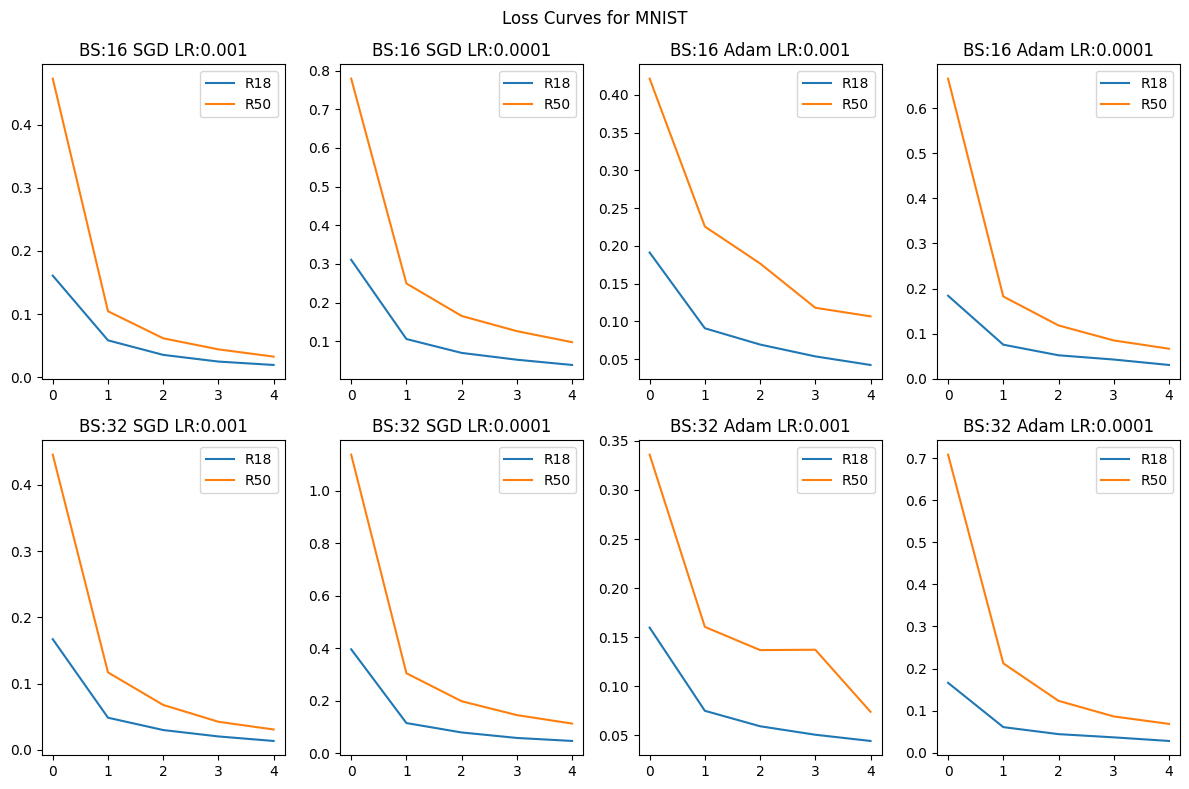

Running: FashionMNIST | ResNet-18 | BS:16 | SGD | LR:0.001


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.8MB/s]


Epoch 1/5 Loss: 0.5275
Epoch 2/5 Loss: 0.3476
Epoch 3/5 Loss: 0.2964
Epoch 4/5 Loss: 0.2651
Epoch 5/5 Loss: 0.2368
Running: FashionMNIST | ResNet-50 | BS:16 | SGD | LR:0.001
Epoch 1/5 Loss: 0.8458
Epoch 2/5 Loss: 0.4638
Epoch 3/5 Loss: 0.3876
Epoch 4/5 Loss: 0.3476
Epoch 5/5 Loss: 0.3114
Running: FashionMNIST | ResNet-18 | BS:16 | SGD | LR:0.0001
Epoch 1/5 Loss: 0.6222
Epoch 2/5 Loss: 0.4047
Epoch 3/5 Loss: 0.3531
Epoch 4/5 Loss: 0.3144
Epoch 5/5 Loss: 0.2871
Running: FashionMNIST | ResNet-50 | BS:16 | SGD | LR:0.0001
Epoch 1/5 Loss: 1.0563
Epoch 2/5 Loss: 0.6807
Epoch 3/5 Loss: 0.5912
Epoch 4/5 Loss: 0.5301
Epoch 5/5 Loss: 0.4842
Running: FashionMNIST | ResNet-18 | BS:16 | Adam | LR:0.001
Epoch 1/5 Loss: 0.5269
Epoch 2/5 Loss: 0.3750
Epoch 3/5 Loss: 0.3221
Epoch 4/5 Loss: 0.2842
Epoch 5/5 Loss: 0.2613
Running: FashionMNIST | ResNet-50 | BS:16 | Adam | LR:0.001
Epoch 1/5 Loss: 0.8548
Epoch 2/5 Loss: 0.5712
Epoch 3/5 Loss: 0.4977
Epoch 4/5 Loss: 0.4277
Epoch 5/5 Loss: 0.3790
Running: Fa

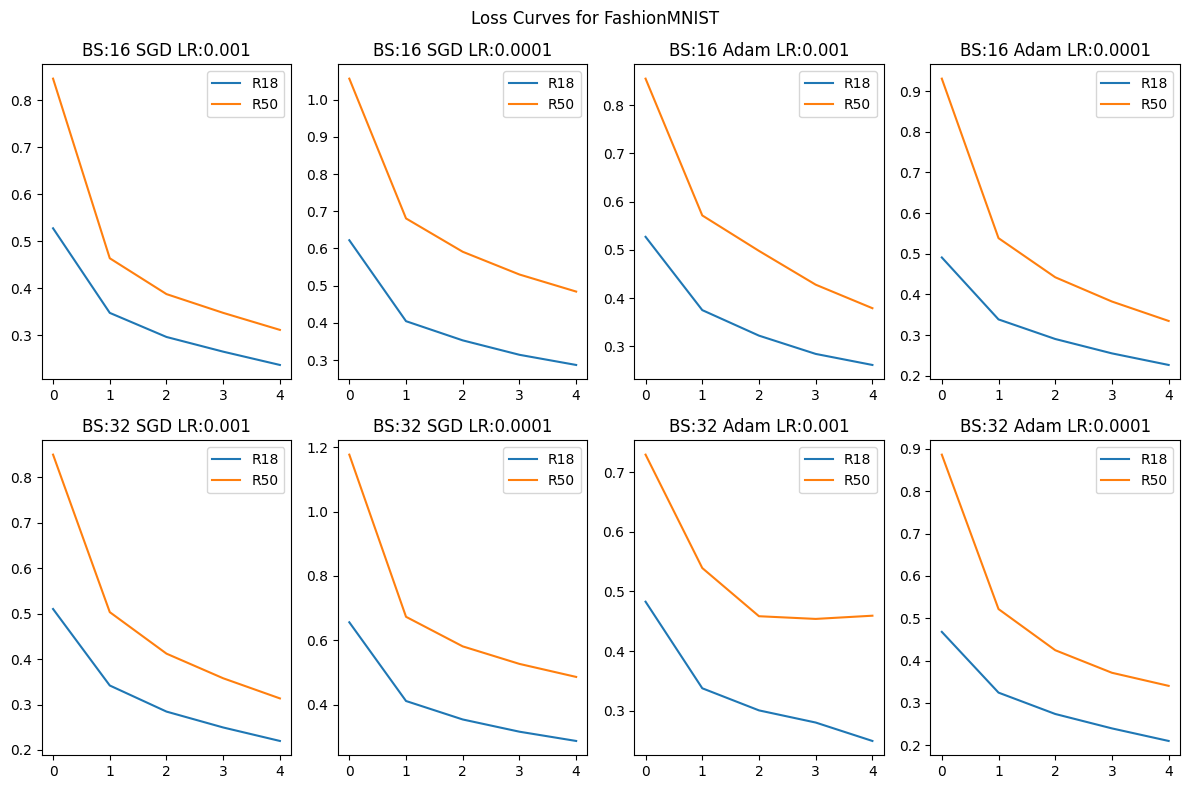

Dataset      | BS  | Opt   | LR      | R18 Acc  | R50 Acc 
MNIST        | 16  | SGD   | 0.001   | 98.92%   | 98.57%
MNIST        | 16  | SGD   | 0.0001  | 98.87%   | 97.79%
MNIST        | 16  | Adam  | 0.001   | 98.95%   | 98.69%
MNIST        | 16  | Adam  | 0.0001  | 98.92%   | 98.06%
MNIST        | 32  | SGD   | 0.001   | 99.04%   | 98.51%
MNIST        | 32  | SGD   | 0.0001  | 98.43%   | 96.61%
MNIST        | 32  | Adam  | 0.001   | 98.93%   | 97.98%
MNIST        | 32  | Adam  | 0.0001  | 98.89%   | 97.43%
FashionMNIST | 16  | SGD   | 0.001   | 90.55%   | 88.51%
FashionMNIST | 16  | SGD   | 0.0001  | 89.66%   | 84.71%
FashionMNIST | 16  | Adam  | 0.001   | 90.67%   | 87.26%
FashionMNIST | 16  | Adam  | 0.0001  | 90.21%   | 88.36%
FashionMNIST | 32  | SGD   | 0.001   | 89.22%   | 87.69%
FashionMNIST | 32  | SGD   | 0.0001  | 88.43%   | 83.82%
FashionMNIST | 32  | Adam  | 0.001   | 90.37%   | 77.94%
FashionMNIST | 32  | Adam  | 0.0001  | 90.86%   | 87.70%


In [ ]:
# --- Experiment Runner ---
datasets = ['MNIST', 'FashionMNIST']
# Following the table structure: [Batch Size, Optimizer, LR]
configs = [
    (16, 'SGD', 0.001), (16, 'SGD', 0.0001),
    (16, 'Adam', 0.001), (16, 'Adam', 0.0001),
    (32, 'SGD', 0.001), (32, 'SGD', 0.0001), # Optional Included
    (32, 'Adam', 0.001), (32, 'Adam', 0.0001) # Optional Included
]

results = {}

# Set specific experiment constants here
EPOCHS_EXP_1 = 5 # Example Epoch Experiment 1
EPOCHS_EXP_2 = 10 # Example Epoch Experiment 2
PIN_MEMORY = True # Can toggle to False

for ds in datasets:
    plt.figure(figsize=(12, 8))
    for i, (bs, opt, lr) in enumerate(configs):
        # Using Epoch Exp 1 for the main table generation to save time
        acc_r18, loss_r18 = train_and_evaluate(ds, 'ResNet-18', bs, opt, lr, EPOCHS_EXP_1, PIN_MEMORY)
        acc_r50, loss_r50 = train_and_evaluate(ds, 'ResNet-50', bs, opt, lr, EPOCHS_EXP_1, PIN_MEMORY)

        results[(ds, bs, opt, lr)] = {'ResNet-18': acc_r18, 'ResNet-50': acc_r50}

        # Plotting Loss Curves
        plt.subplot(2, 4, i+1)
        plt.plot(loss_r18, label='R18')
        plt.plot(loss_r50, label='R50')
        plt.title(f"BS:{bs} {opt} LR:{lr}")
        plt.legend()

    plt.suptitle(f'Loss Curves for {ds}')
    plt.tight_layout()
    plt.show()

# Print Final Table Data
print(f"{'Dataset':<12} | {'BS':<3} | {'Opt':<5} | {'LR':<7} | {'R18 Acc':<8} | {'R50 Acc':<8}")
for key, val in results.items():
    ds, bs, opt, lr = key
    print(f"{ds:<12} | {bs:<3} | {opt:<5} | {lr:<7} | {val['ResNet-18']:.2f}%   | {val['ResNet-50']:.2f}%")

In [6]:
def get_numpy_data(loader, max_samples=None):
    """
    Extracts flattened numpy arrays from a PyTorch loader.
    """
    X_list, y_list = [], []
    total = 0
    for images, labels in loader:
        # Flatten: (B, 3, 32, 32) -> (B, 3072)
        flat_images = images.view(images.size(0), -1).numpy()
        X_list.append(flat_images)
        y_list.append(labels.numpy())

        total += labels.size(0)
        if max_samples and total >= max_samples:
            break

    return np.concatenate(X_list)[:max_samples], np.concatenate(y_list)[:max_samples]

def run_svm_experiments(datasets, kernels=['poly', 'rbf']):
    print(f"{'Dataset':<12} | {'Kernel':<6} | {'Acc (%)':<8} | {'Time (ms)':<10}")
    print("-" * 50)

    for ds_name in datasets:
        # 1. Get Loaders (Reuse previous function)
        # Note: pin_memory=False is fine for CPU-based extraction
        train_loader, _, test_loader = get_dataloaders(ds_name, batch_size=64, pin_memory=False)

        # 2. Convert to Numpy
        X_train, y_train = get_numpy_data(train_loader)
        X_test, y_test = get_numpy_data(test_loader)

        for kernel in kernels:
            # 3. Define SVM
            clf = svm.SVC(kernel=kernel, gamma='scale')

            # 4. Train & Time
            start_time = time.time()
            clf.fit(X_train, y_train)
            end_time = time.time()
            train_time_ms = (end_time - start_time) * 1000

            # 5. Evaluate
            predictions = clf.predict(X_test)
            acc = accuracy_score(y_test, predictions) * 100

            print(f"{ds_name:<12} | {kernel:<6} | {acc:.2f}%   | {train_time_ms:.0f}")

In [7]:
# --- Run SVM Experiment ---
run_svm_experiments(['MNIST', 'FashionMNIST'])

Dataset      | Kernel | Acc (%)  | Time (ms) 
--------------------------------------------------


100%|██████████| 9.91M/9.91M [00:00<00:00, 22.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 599kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.59MB/s]


MNIST        | poly   | 97.99%   | 443644
MNIST        | rbf    | 97.89%   | 661262


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 230kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.24MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.5MB/s]


FashionMNIST | poly   | 89.50%   | 844565
FashionMNIST | rbf    | 88.87%   | 952153


In [ ]:
!pip install thop

In [ ]:
import time
from thop import profile  # Install via: pip install thop

def get_model(model_name, num_classes=10):
    # Re-defining locally to ensure clean state
    if model_name == 'ResNet-18':
        model = models.resnet18(weights=None)
    elif model_name == 'ResNet-50':
        model = models.resnet50(weights=None)
    # Note: ResNet-32 is not in standard torchvision; skipped to keep code minimal.

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def run_hardware_experiment(device_type, model_name, batch_size, opt_name, lr, epochs=1):
    device = torch.device(device_type)
    print(f"Running: {device_type} | {model_name} | {opt_name} | LR:{lr}")

    # 1. Data Setup (FashionMNIST)
    train_loader, _, test_loader = get_dataloaders('FashionMNIST', batch_size, pin_memory=False)

    # 2. Model Setup
    model = get_model(model_name).to(device)

    # 3. Calculate FLOPs (using a dummy input on the correct device)
    dummy_input = torch.randn(1, 3, 32, 32).to(device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)

    # 4. Optimizer
    criterion = nn.CrossEntropyLoss()
    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else: # Adam
        optimizer = optim.Adam(model.parameters(), lr=lr)

    # 5. Training with Timing
    model.train()

    # Synchronization for accurate GPU timing
    if device_type == 'cuda': torch.cuda.synchronize()
    start_time = time.time()

    for epoch in range(epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    if device_type == 'cuda': torch.cuda.synchronize()
    end_time = time.time()

    total_train_time_ms = (end_time - start_time) * 1000  # Convert seconds to ms

    # 6. Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy, total_train_time_ms, flops


In [ ]:
# --- Run Experiments for Table 2 ---
hardware_configs = [
    ('cpu', 16, 'SGD', 0.001),
    ('cpu', 16, 'Adam', 0.001),
    ('cuda', 16, 'SGD', 0.001),
    ('cuda', 16, 'Adam', 0.001)
]

print(f"{'Device':<6} | {'BS':<3} | {'Opt':<5} | {'Model':<9} | {'Acc (%)':<8} | {'Time (ms)':<10} | {'FLOPs'}")
print("-" * 75)

for dev, bs, opt, lr in hardware_configs:
    if dev == 'cuda' and not torch.cuda.is_available():
        print(f"Skipping {dev} (not available)")
        continue

    for m_name in ['ResNet-18', 'ResNet-50']:
        # Run for small epochs (e.g., 1) just to get timing/flops as per requirement
        acc, t_time, flops = run_hardware_experiment(dev, m_name, bs, opt, lr, epochs=1)

        print(f"{dev:<6} | {bs:<3} | {opt:<5} | {m_name:<9} | {acc:.2f}%   | {t_time:.0f} ms | {flops:.0f}")

Device | BS  | Opt   | Model     | Acc (%)  | Time (ms)  | FLOPs
---------------------------------------------------------------------------
Running: cpu | ResNet-18 | SGD | LR:0.001
cpu    | 16  | SGD   | ResNet-18 | 87.43%   | 605992 ms | 37220352
Running: cpu | ResNet-50 | SGD | LR:0.001
cpu    | 16  | SGD   | ResNet-50 | 80.39%   | 1352004 ms | 84342784
Running: cpu | ResNet-18 | Adam | LR:0.001
cpu    | 16  | Adam  | ResNet-18 | 85.01%   | 807527 ms | 37220352
Running: cpu | ResNet-50 | Adam | LR:0.001
